## **SREINet dealing with nonseparable multivariate candidate functions**


## **I. Setup and Preprocessing**

In [48]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

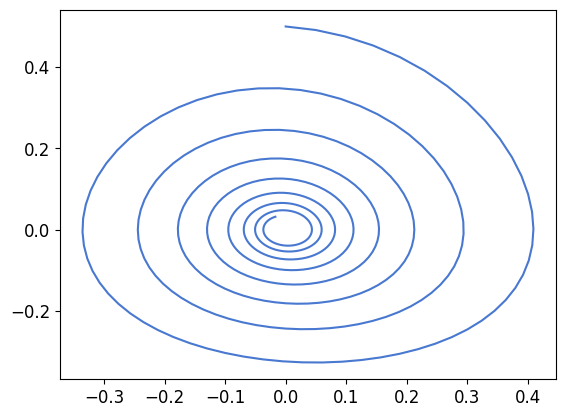

Training input shape: (500, 2)
Training output shape: (500, 2)


In [95]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odefun(t, x):
    x1, x2 = x
    dx1dt = x2 
    dx2dt = -x1 - 0.1*x2 - np.sin(x1 * x2)
    return [dx1dt, dx2dt]


t_span = (0, 50)                    
y0 = [0, 0.5]   # initial conditions
dt = 0.1

# Initialize DataGenerator with correct parameters
myDG = DG.DataGenerator(
    initial_conditions=[y0],         # list of ICs
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

x_train, dx_train = myDG.generate_ode_traj_with_ic(odefun, y0)

t_arr = np.arange(myDG.t0, myDG.T, myDG.dt)

#plot x_train and dx_train

plt.plot(x_train[:,0], x_train[:,1])
plt.show()


#Shuffle data
training_input, training_output = x_train, dx_train
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

#shuffle data

training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [50]:
# Set mini-batch size
MINI_BATCH_SIZE = 8
learning_rate = 0.01

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [51]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guess_highest_order_polynomial = 6 # depth of SREINet

layer_depth = guess_highest_order_polynomial

layer_neuron_nums_per_act_fn = [dim] * layer_depth

## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [52]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=0.1, seed=42), # stddev should be tuned for deep SREINet to avoid vanishing gradients
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            tf.random.set_seed(np.random.randint(10000))
            model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")

### **2.2 Loss Function**

In [53]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [54]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Training with Pruning**

In [55]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   

def SREINet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=0,       # Threshold for early stopping based on training and validation loss
    early_stopping_pruning_threshold=0,    # Threshold for early stopping based on pruning schedule
    verbose=0               # Verbosity mode (0 = silent, 1 = progress bar, etc.)
):
    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def generate_binary_mask_and_prune_weight(model, pruning_weight_threshold):
        binary_masks = []  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started
        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch]
        binary_mask = generate_binary_mask_and_prune_weight(model, current_pruning_threshold)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        #calculate the average of val_loss
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()

        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose:
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            print(f"Epoch {epoch + 1:3.0f}:"
                f"  Train Loss: {current_train_loss:9.4e}"
                f",  Validation Loss: {current_val_loss:9.4e}"
                # f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
                f",  Epoch Time: {epoch_time:.2f}s"  
                f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")    
            
        if model.stop_training: # Stop training if all the layers are untrianable
            break   

        # Check for early stopping
        if current_train_loss < early_stopping_loss_threshold and current_pruning_threshold > early_stopping_pruning_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_val_loss:.12f} is below the threshold {early_stopping_loss_threshold:.12f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

#### **Pruning Profile**

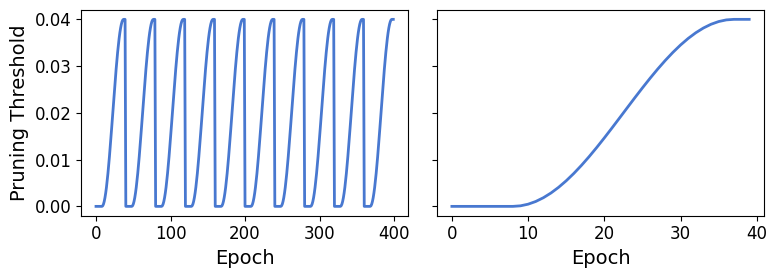

In [56]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.04 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 15
PRUNING_EPOCHS_PER_PERIOD = 40
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule
pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    #zero_percentage=0.10,
                                                    show_plot=True)

### Training

In [57]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-8   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.02

training_histories = []
weights_list = []

In [58]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = SREINet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.20,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based)
        verbose=1                   # Hide the epoch steps
    )
    
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('SREINet').get_weights()])
   

Training dimension 1...
Epoch   1:  Train Loss: 1.8843e-02,  Validation Loss: 1.4962e-02,  Epoch Time: 0.32s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 1.0780e-02,  Validation Loss: 1.7902e-03,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 2.8416e-04,  Validation Loss: 1.9574e-05,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 5.5658e-06,  Validation Loss: 3.1288e-06,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 1.8423e-06,  Validation Loss: 2.1909e-06,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 2.3901e-06,  Validation Loss: 2.0777e-06,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 1.3106e-06,  Validation Loss: 7.6026e-07,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 1.1471e-06,  Validation Loss: 5.6497e-07,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   9:  Train Loss: 1.2203e-06,  Validation 

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [59]:
def generate_set_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)] 

#### `coefficient_reconstruction`

In [60]:
def coefficient_reconstruction(dim_index,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = max(max(len(layer) for layer in SREINet) for SREINet in weights)
    
    labels = generate_set_labels(max_neurons - 1) # number of states = number of neurons - 1

    def explore_path(SREINet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[SREINet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[SREINet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(SREINet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_SREINet_products = []
    for SREINet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[SREINet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(SREINet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        SREINet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in SREINet_products:
                SREINet_products[label_counts_key] += weight_product
            else:
                SREINet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        SREINet_products = {k: v for k, v in SREINet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_SREINet_products = dict(sorted(SREINet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_SREINet_products = SREINet_products

        all_SREINet_products.append(sorted_SREINet_products)

    #output formatting
    labeled_all_SREINet_products = []
    for SREINet_index, sorted_SREINet_products in enumerate(all_SREINet_products):
        SREINet_product_strings = []
        for key, value in sorted_SREINet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if SREINet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            SREINet_product_strings.append(term_str)

        formatted_output = ''.join(SREINet_product_strings)
        layer_prefix = f"(x{SREINet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_SREINet_products.append(full_output)

    return labeled_all_SREINet_products

## **V. Results**
### **Identified Model**

In [87]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,weights_list[i], 
                                            minimum_coefficient_threshold = 5e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(x1)'= 0.9997657044*x2
(x2)'=  - 0.9990676889*x1 - 0.1006411724*x2 - 0.9990830437*x1*x2


### **Validation**

In [206]:
params = {
    'image.origin': 'lower',
    'image.interpolation': 'nearest',
    'image.cmap': 'gray',
    'axes.grid': False,
    'savefig.dpi': 600,  # to adjust notebook inline plot size
    'axes.labelsize': 16, # fontsize for x and y labels (was 10)
    'axes.titlesize': 16,
    'font.size': 14, # was 10
    'legend.fontsize': 12, # was 10
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'text.usetex': False,
    #'figure.figsize': [7, 4],
    'font.family': 'Helvetica',
    #'text.latex.preamble': r'\usepackage{amsmath}',  # Optional, for advanced math symbols
    #'axes.labelweight': 'bold'
    }
import matplotlib

matplotlib.rcParams.update(params)


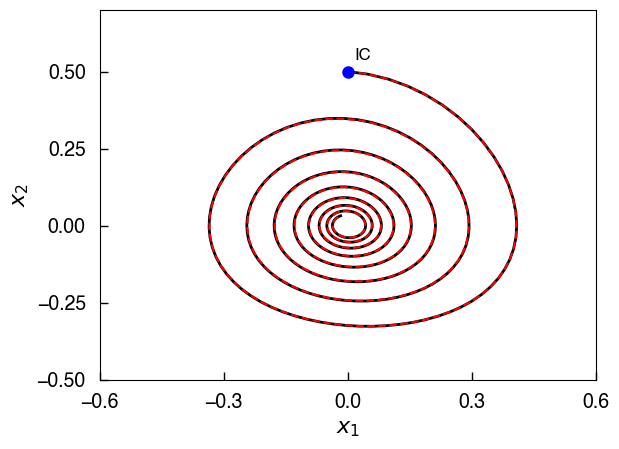

In [207]:
def identifed_ode(t, x):
    x1, x2 = x
    dx1dt = 0.9997657044*x2 
    dx2dt = - 0.9990676889*x1 - 0.1006411724*x2 - 0.9990830437*x1*x2 # copy from the identified model
    return [dx1dt, dx2dt]

#validation using training initial conditions

val_DG = DG.DataGenerator(
    initial_conditions=[y0],         # list of ICs
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

val_x, val_dx = val_DG.generate_ode_traj_with_ic(identifed_ode, y0)

true_x, true_y = myDG.generate_ode_traj_with_ic(odefun, y0)

plt.plot(true_x[:,0], true_x[:,1], label='Ground Truth',color='black', linewidth=2)

plt.plot(val_x[:,0], val_x[:,1], label='Identified Model',color='red',linestyle='--')

plt.plot(true_x[0,0], true_x[0,1], 'bo', markersize=8)

plt.annotate('IC', (true_x[0,0], true_x[0,1]), 
             xytext=(5, 8), textcoords='offset points',
             fontsize=12, ha='left')

plt.xlim([-0.6,0.6])
plt.xticks([-0.6, -0.3, 0, 0.3, 0.6])
plt.ylim([-0.5,0.7])
plt.yticks([-0.5, -0.25, 0, 0.25, 0.5])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.tick_params(direction='in', length=6, width=1)
plt.tick_params(axis='y', pad=10)
plt.tick_params(axis='x', pad=10)

#plt.legend()
plt.show()


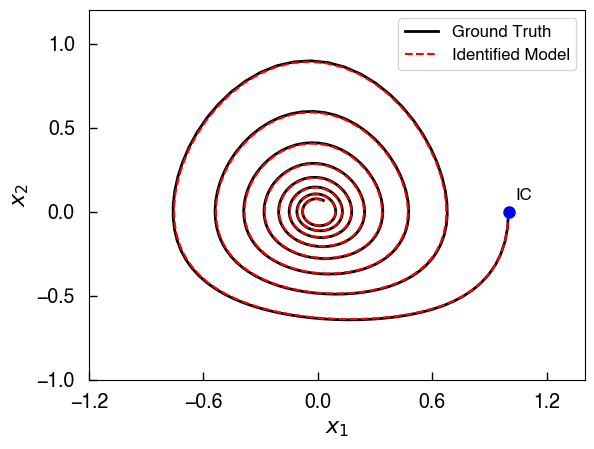

In [208]:
# validation using different initial conditions
val_y0 = [1.0, 0.0]

val_DG = DG.DataGenerator(
    initial_conditions=[val_y0],         # list of ICs
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

val_x, val_dx = val_DG.generate_ode_traj_with_ic(identifed_ode, val_y0)

true_x, true_y = myDG.generate_ode_traj_with_ic(odefun, val_y0)

plt.plot(true_x[:,0], true_x[:,1], label='Ground Truth',color='black',linewidth=2)

plt.plot(val_x[:,0], val_x[:,1], label='Identified Model',color='red',linestyle='--')

plt.plot(true_x[0,0], true_x[0,1], 'bo', markersize=8)

plt.annotate('IC', (true_x[0,0], true_x[0,1]), 
             xytext=(5, 8), textcoords='offset points',
             fontsize=12, ha='left')

plt.xlim([-1.2,1.4])
plt.xticks([-1.2,-0.6, 0, 0.6, 1.2])
plt.ylim([-1.0,1.2])
plt.yticks([-1.0,-0.5, 0, 0.5, 1.0])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.tick_params(direction='in', length=6, width=1)
plt.tick_params(axis='y', pad=10)
plt.tick_params(axis='x', pad=10)


plt.legend()
plt.show()

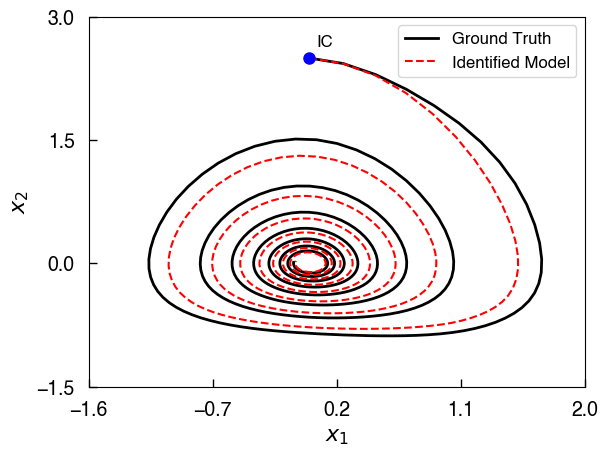

In [209]:
# validation using different initial conditions
val_y0 = [0.0, 2.5]

val_DG = DG.DataGenerator(
    initial_conditions=[val_y0],         # list of ICs
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

val_x, val_dx = val_DG.generate_ode_traj_with_ic(identifed_ode, val_y0)

true_x, true_y = myDG.generate_ode_traj_with_ic(odefun, val_y0)

plt.plot(true_x[:,0], true_x[:,1], label='Ground Truth',color='black',linewidth=2)

plt.plot(val_x[:,0], val_x[:,1], label='Identified Model',color='red',linestyle='--')

plt.plot(true_x[0,0], true_x[0,1], 'bo', markersize=8)

plt.annotate('IC', (true_x[0,0], true_x[0,1]), 
             xytext=(5, 8), textcoords='offset points',
             fontsize=12, ha='left')

plt.xlim([-1.6,2.0])
plt.xticks([-1.6,-0.7,0.2, 1.1, 2.0])
plt.ylim([-1.5,3.0])
plt.yticks([-1.5,0, 1.5, 3.0])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.tick_params(direction='in', length=6, width=1)
plt.tick_params(axis='y', pad=10)
plt.tick_params(axis='x', pad=10)


plt.legend()
plt.show()